In [8]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Vivianne\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


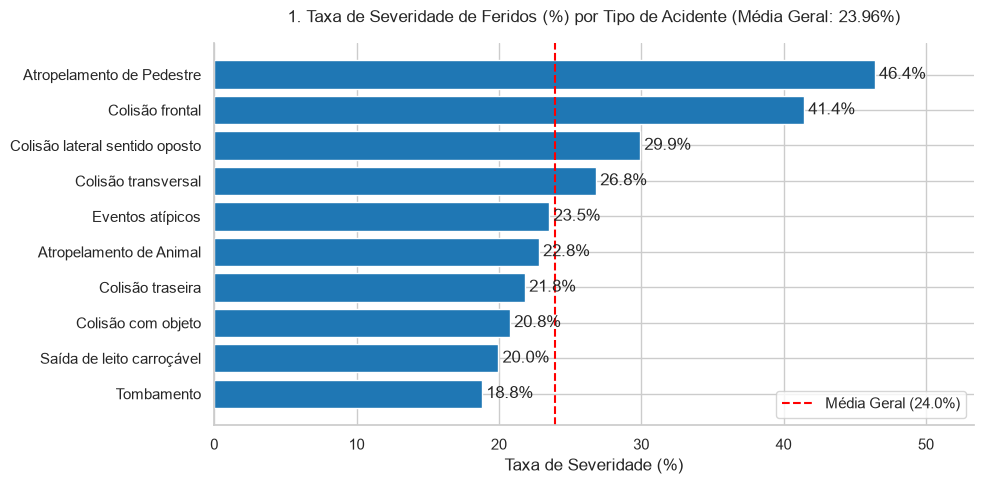

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Cálculo do total e agregação da taxa de severidade
df["tot"] = df["feridos_leves"] + df["feridos_graves"]
kpi = df.groupby("tipo_acidente")[["feridos_graves", "tot"]].sum()
kpi["taxa"] = kpi["feridos_graves"] / kpi["tot"] * 100
kpi = kpi[kpi["tot"] > 100].sort_values("taxa").tail(10)

med = df["feridos_graves"].sum() / df["tot"].sum() * 100

# 2. Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(kpi.index, kpi["taxa"], color="#1f77b4")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.axvline(
    med, color="red", linestyle="--", label=f"Média Geral ({med:.1f}%)"
)

plt.title(
    f"1. Taxa de Severidade de Feridos (%) por Tipo de Acidente (Média Geral:"
    f" {med:.2f}%)",
    pad=15,
)
plt.xlabel("Taxa de Severidade (%)")
plt.xlim(0, kpi["taxa"].max() * 1.15)
plt.legend(loc="lower right")
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

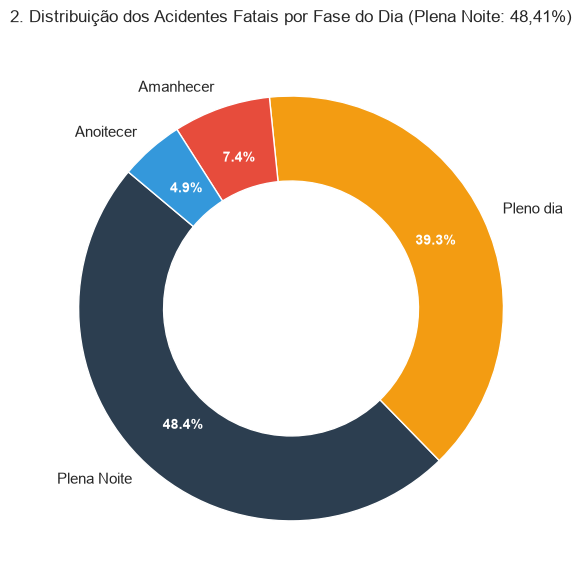

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

# Célula 2 - Concentração Noturna de Fatalidades (%)
kpi2_df = df[df["acidente_fatal"] == 1]["fase_dia"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = ["#2c3e50", "#f39c12", "#e74c3c", "#3498db"]

wedges, texts, autotexts = ax.pie(
    kpi2_df,
    labels=kpi2_df.index,
    autopct="%1.1f%%",
    pctdistance=0.75,  # Centraliza o texto no meio da fatia
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="w"),
)

for autotext in autotexts:
  autotext.set_color("white")
  autotext.set_weight("bold")
  autotext.set_fontsize(10)

plt.title(
    "2. Distribuição dos Acidentes Fatais por Fase do Dia (Plena Noite:"
    " 48,41%)",
    fontsize=12,
    pad=15,
)
plt.tight_layout()
plt.show()

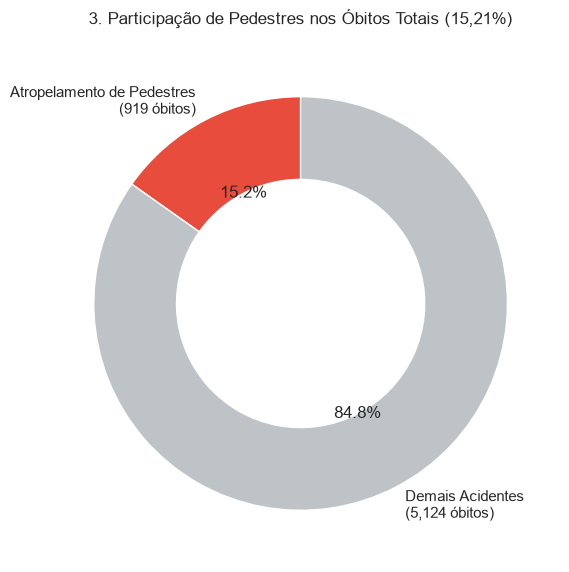

In [17]:
# Célula 3 - Participação de Pedestres nos Óbitos Totais (%)
pedestre_mortos = df[df["tipo_acidente"].str.contains("Pedestre", na=False)][
    "mortos"
].sum()
outros_mortos = df["mortos"].sum() - pedestre_mortos

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [pedestre_mortos, outros_mortos],
    labels=[
        f"Atropelamento de Pedestres\n({pedestre_mortos:,} óbitos)",
        f"Demais Acidentes\n({outros_mortos:,} óbitos)",
    ],
    colors=["#e74c3c", "#bdc3c7"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor="w"),
)

plt.title(
    "3. Participação de Pedestres nos Óbitos Totais (15,21%)",
    fontsize=12,
    pad=15,
)
plt.tight_layout()
plt.show()

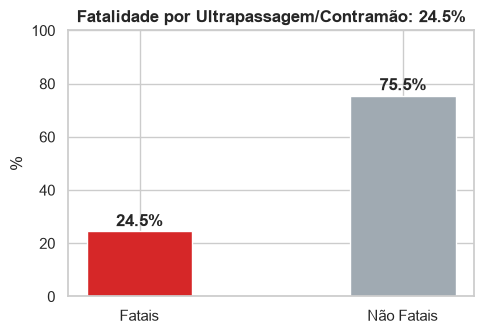

In [23]:
# 4. Percentual de Fatalidade por Ultrapassagem / Contramão (%)
df_c = df[df["causa_acidente"].str.contains("Transitar na contramão|Ultrapassagem indevida", case=False, na=False)]
pct = ((df_c["mortos"] > 0).sum() / len(df_c)) * 100

plt.figure(figsize=(5, 3.5))
bars = plt.bar(["Fatais", "Não Fatais"], [pct, 100 - pct], color=["#D62728", "#A0AAB2"], width=0.4)
plt.title(f"Fatalidade por Ultrapassagem/Contramão: {pct:.1f}%", fontweight="bold")
plt.ylabel("%")
plt.ylim(0, 100)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height():.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


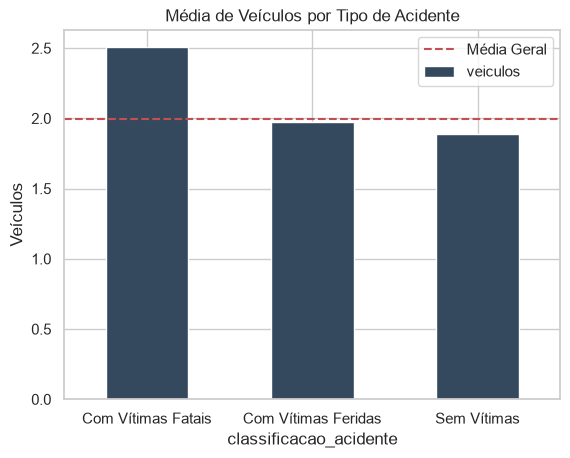

In [21]:
# 5. Média de Veículos Envolvidos por Ocorrência
med = df.groupby("classificacao_acidente")["veiculos"].mean()

med.plot(kind="bar", color="#34495e", rot=0)
plt.axhline(df["veiculos"].mean(), color="r", linestyle="--", label="Média Geral")
plt.title("Média de Veículos por Tipo de Acidente")
plt.ylabel("Veículos")
plt.legend()
plt.show()